# What actually drives the price of rent in Chisinau?

My first look at the data before training anything. ~4,500 monthly-rent listings
scraped from 999.md. Questions: what does normal rent look like here, how much does
location matter, and does the recent energetic crisis affect on the price?

In [1]:
import sys, json
sys.path.append('..') # so I can import features.py from the project root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from features import (clean_data, trim_ppm_outliers, trim_knn_outliers,
                      build_ppm_grid, assign_ppm, impute_medians, numerical, binary)

IMG = '../images' # where I save plots for the README

df_raw = pd.read_csv('../data/raw/listings.csv')
df = clean_data(df_raw)
# clean_data leaves the 1% price/m2 trim, the market-rate trim and the median fill
# to train.py (which fits them per split, to avoid leakage). an EDA has no split,
# so I apply the same steps to the whole set to get the clean view the model
# actually trains on.
df, _ = trim_ppm_outliers(df)
df, _ = impute_medians(df)
grid_ppm, sector_ppm, global_ppm = build_ppm_grid(df)
df['knn_ppm'] = assign_ppm(df, grid_ppm, sector_ppm, global_ppm)
df = trim_knn_outliers(df).copy()
df['price_per_m2'] = df['price'] / df['area']

print('raw listings  :', len(df_raw))
print('after cleaning:', len(df), '(dropped missing price/area, duplicates, outliers, >2000 EUR)')
df[['price', 'price_per_m2', 'rooms', 'area', 'sector', 'building_fund']].head()

raw listings  : 4528
after cleaning: 3358 (dropped missing price/area, duplicates, outliers, >2000 EUR)


,price,price_per_m2,rooms,area,sector,building_fund
0,250.000000,7.812500,1.0,32.0,poșta veche,secundar
1,179.487179,5.608974,1.0,32.0,botanica,secundar
2,499.000000,9.980000,1.0,50.0,centru,construcţii noi
3,600.000000,10.000000,1.0,60.0,centru,construcţii noi
4,340.000000,8.500000,1.0,40.0,buiucani,secundar


#### Lots of normal flats and a tail of expensive ones. The log makes it symmetric -
#### that's why the model trains on `log(price)`.

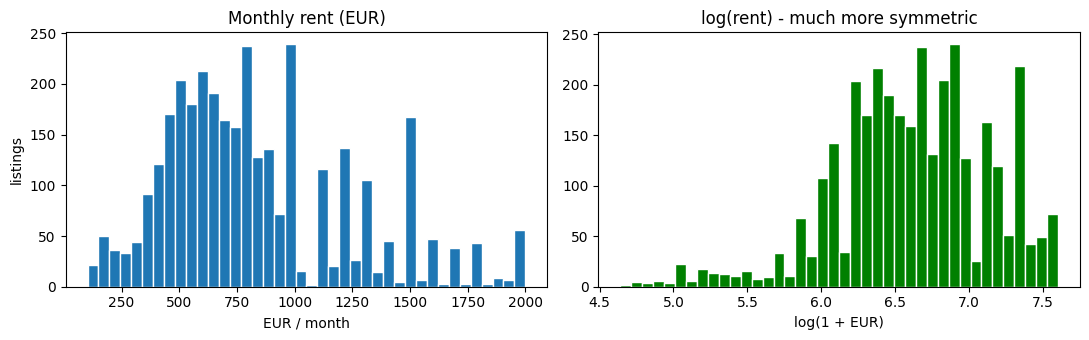

median rent: 780 EUR/month
median EUR/m2: 11.8


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df['price'], bins=40, edgecolor='white')
ax[0].set(title='Monthly rent (EUR)', xlabel='EUR / month', ylabel='listings')
ax[1].hist(np.log1p(df['price']), bins=40, color='green',edgecolor='white')
ax[1].set(title='log(rent) - much more symmetric', xlabel='log(1 + EUR)')
plt.tight_layout(); plt.savefig(f'{IMG}/rent_distribution.png', bbox_inches='tight'); plt.show()

print('median rent:', int(df['price'].median()), 'EUR/month')
print('median EUR/m2:', round(df['price_per_m2'].median(), 1))

### Now, I would like to compare rent per m2 by sectors:

In [3]:
by_sector = df.groupby('sector').agg(
    listings=('price', 'size'), 
    median_rent=('price', 'median'),
    eur_per_m2=('price_per_m2', 'mean'))

by_sector = by_sector[by_sector['listings'] >= 10].sort_values('eur_per_m2')
print(by_sector.round(1))

             listings  median_rent  eur_per_m2
sector                                        
poșta veche        38        450.0         8.5
telecentru        147        550.0        10.0
ciocana           227        550.0        10.2
botanica          525        600.0        10.8
buiucani          345        640.0        10.9
sculeni            20        700.0        12.0
râșcani           425        800.0        12.8
centru           1629        950.0        13.6


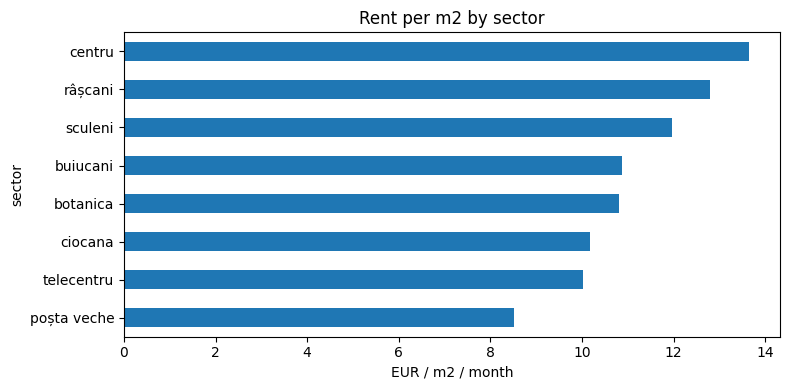

In [4]:
by_sector['eur_per_m2'].plot.barh(figsize=(8, 4))
plt.title('Rent per m2 by sector')
plt.xlabel('EUR / m2 / month')
plt.tight_layout()
plt.savefig(f'{IMG}/price_per_sector.png', bbox_inches='tight')
plt.show()

### Let's see how much is one extra m2 worth:

In [5]:
print('EUR/m2 by rooms:')

print(df.groupby('rooms')['price_per_m2'].mean().round(1))

EUR/m2 by rooms:
rooms
1.0    12.6
2.0    12.3
3.0    12.2
4.0    10.5
5.0     7.5
Name: price_per_m2, dtype: float64


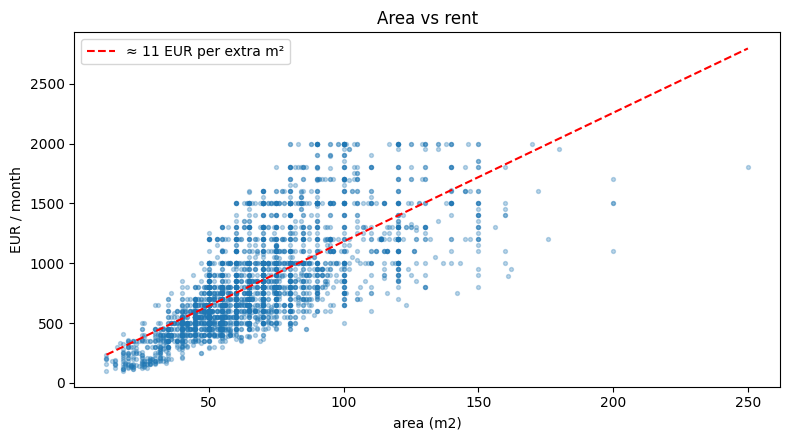

In [6]:
slope, intercept = np.polyfit(df['area'], df['price'], 1)

plt.figure(figsize=(8, 4.5))
plt.scatter(df['area'], df['price'], s=8, alpha=0.3)
xs = np.array([df['area'].min(), df['area'].max()])
plt.plot(xs, intercept + slope * xs, 'r--', label=f'≈ {slope:.0f} EUR per extra m²')

plt.xlabel('area (m2)')
plt.ylabel('EUR / month')
plt.title('Area vs rent')

plt.legend()
plt.tight_layout()

plt.savefig(f'{IMG}/area_vs_rent.png', bbox_inches='tight'); plt.show()

### Since Moldova has gone recently through an energetic crisis, we may assume that autonomous heating may affect the price.
#### let's check it on real scraped data.

everyone says flats with their own heating rent for more, and the raw numbers agree.
but autonomous heating is standard in new buildings, and new buildings are expensive
for other reasons too. so I check the premium inside each building fund.

In [7]:
with_h = df[df['autonomous_heating'] == 1]['price_per_m2'].mean()
without_h = df[df['autonomous_heating'] == 0]['price_per_m2'].mean()
print(f'raw premium: {with_h:.2f} vs {without_h:.2f} EUR/m2 ({(with_h / without_h - 1) * 100:+.1f}%)')

raw premium: 12.75 vs 11.97 EUR/m2 (+6.6%)


In [8]:
heat_table = (df.groupby(['building_fund', 'autonomous_heating'])['price_per_m2']
         .mean().unstack().round(2))
heat_table.columns = ['no / central', 'autonomous']
print('\nsame comparison inside each building fund:')
print(heat_table)


same comparison inside each building fund:
                 no / central  autonomous
building_fund                            
construcţii noi         13.26       12.95
secundar                 9.97       10.18


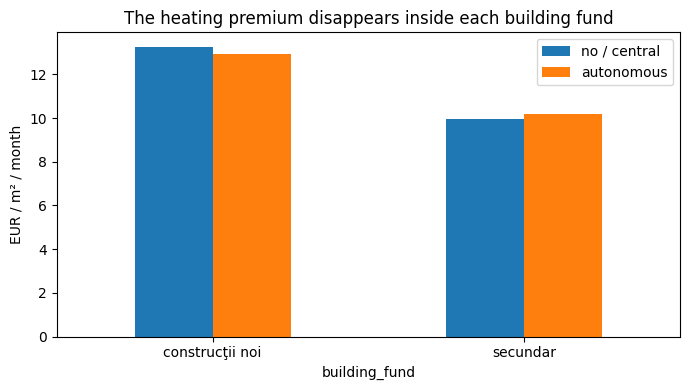

In [9]:
heat_table.plot.bar(rot=0, figsize=(7, 4))
plt.title('The heating premium disappears inside each building fund')
plt.ylabel('EUR / m² / month')
plt.tight_layout()
plt.savefig(f'{IMG}/heating_premium.png', bbox_inches='tight')
plt.show()

## Checking new build vs old Soviet stock

In [10]:
by_fund = (df.groupby('building_fund')
             .agg(listings=('price', 'size'),
                  eur_per_m2=('price_per_m2', 'mean'),
                  median_rent=('price', 'median')).round(1))
print(by_fund)

                 listings  eur_per_m2  median_rent
building_fund                                     
construcţii noi      2554        13.1        850.0
secundar              804        10.0        450.0


In [11]:
gap = (by_fund.loc['construcţii noi', 'eur_per_m2'] / by_fund.loc['secundar', 'eur_per_m2'] - 1) * 100
print(f'new-build premium: {gap:+.0f}% per m2')

new-build premium: +31% per m2


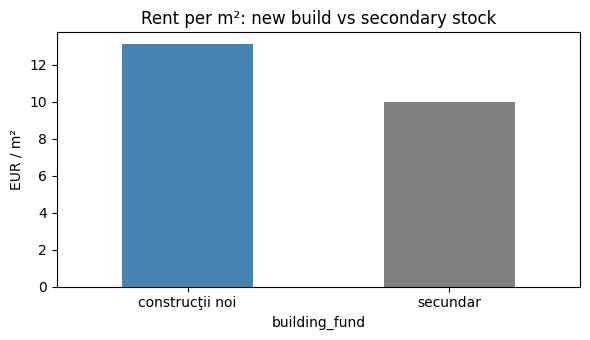

In [12]:
by_fund['eur_per_m2'].plot.bar(rot=0, figsize=(6, 3.5), color=['steelblue', 'gray'])
plt.title('Rent per m²: new build vs secondary stock')
plt.ylabel('EUR / m²')
plt.tight_layout()
plt.savefig(f'{IMG}/newbuild_gap.png', bbox_inches='tight')
plt.show()

## What correlates with rent the most?

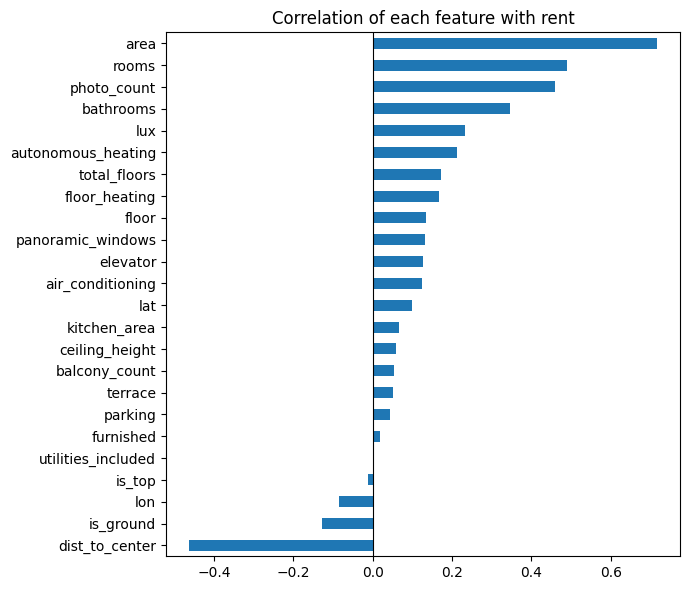

In [13]:
corr = df[numerical + binary + ['price']].corr()['price'].drop('price').sort_values()
corr.plot.barh(figsize=(7, 6))
plt.title('Correlation of each feature with rent')
plt.axvline(0, color='k', lw=0.8)
plt.tight_layout()
plt.savefig(f'{IMG}/correlation.png', bbox_inches='tight')
plt.show()

In [14]:
# the raw premiums the summary below quotes: mean EUR/m2 with a flag vs without
def premium(flag):
    a = df[df[flag] == 1]['price_per_m2'].mean()
    b = df[df[flag] == 0]['price_per_m2'].mean()
    return (a / b - 1) * 100

for f in ['floor_heating', 'air_conditioning', 'furnished', 'is_ground', 'is_top', 'lux']:
    print(f'{f:18s} {premium(f):+5.1f}%')
print(f'{'extra m2':18s} {np.polyfit(df['area'], df['price'], 1)[0]:+5.1f} EUR/month')

floor_heating      +12.8%
air_conditioning    +6.7%
furnished           -3.0%
is_ground          -10.2%
is_top              -4.7%
lux                +18.4%
extra m2           +10.8 EUR/month


## Key insights

From ~3,370 clean listings (median **750 EUR/mo**, **11.7 EUR/m2**, mass segment <= 2,000 EUR):

- **Location affects the most**: Centru 13.6 EUR/m2 vs 8.5-10.9 EUR/m2 in the outer
  sectors, and the map shows a clean centre-outward gradient.
- **New build vs old: +32% per m2** (13.1 EUR vs 9.9 EUR) - the biggest gap of any
  single category.
- **The autonomous heating is not a driver at all:** raw it's +7%, but inside each
  building fund it vanishes (new: 13.0 with vs 13.2 without; old: ~10 either way).
  It was the new-building premium all along.
- Floor heating (+14%) and air conditioning (+7%) show decent raw premiums - but after
  the heating lesson I would bet a chunk of that is the same new-build effect.
- The new **lux flag is +19% per m2 raw** - ads that mention penthouse / premium /
  jacuzzi really do ask more, even inside the mass segment.
- **Furnishing adds nothing per m2** (-3.0%) - it's simply expected here.
- **Ground floor is a real discount (-10%)**, top floor a small one (-5%).
- Each extra m2 ~ **+11 EUR/month**, and small flats are pricier per m2.
- The distribution has a long tail -> the model trains on `log(price)`.